In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 


In [8]:
disaster_df = pd.read_csv('../data/raw/disaster_dataset_cleaned.csv')
area_df = pd.read_csv('../data/raw/areas.csv')
incident_df = pd.read_csv('../data/raw/incident_dataset.csv') 
resource_df = pd.read_csv('../data/raw/resources.csv')

In [13]:
datasets = {
    "Disaster": disaster_df,
    "Area": area_df,
    "Incident": incident_df,
    "Resource": resource_df
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isnull().sum())


Disaster
Shape: (432, 37)

Columns:
['DisNo.', 'Historic', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update', 'Start Date', 'End Date']

Missing values:
DisNo.                                   0
Historic                                 0
Disaster Group                           0
Disaster Subgroup                        0
Disaster Type                            0
Disaster Subtype                         0
Event Name                             376
ISO            

In [15]:
disaster_df.head()

,DisNo.,Historic,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Event Name,ISO,Country,Subregion,...,"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update,Start Date,End Date
0,2026-0330-IND,No,Natural,Meteorological,Storm,Lightning/Thunderstorms,NaN,IND,India,Southern Asia,...,NaN,10000.0,NaN,NaN,NaN,NaN,2026-05-15,2026-07-24,2026-05-13,2026-05-13
1,2025-1102-IND,No,Natural,Meteorological,Extreme temperature,Heat wave,NaN,IND,India,Southern Asia,...,NaN,NaN,NaN,100.000000,NaN,NaN,2026-08-28,2026-08-28,2025-04-01,2025-07-01
2,2001-0729-IND,No,Natural,Meteorological,Storm,Tropical cyclone,NaN,IND,India,Southern Asia,...,NaN,NaN,NaN,54.999385,"[{""adm1_code"":1490,""adm1_name"":""Goa""},{""adm1_c...","[{""gid_1"":""IND.10_1"",""migration_date"":""2025-12...",2003-07-01,2026-08-26,2001-05-28,2001-05-28
3,2000-0332-IND,No,Natural,Hydrological,Flood,Flash flood,NaN,IND,India,Southern Asia,...,NaN,NaN,NaN,53.487737,"[{""adm2_code"":17582,""adm2_name"":""Golaghat""},{""...","[{""gid_2"":""IND.3.11_1"",""migration_date"":""2025-...",2005-09-15,2025-12-20,2000-06-10,2000-06-10
4,2010-0416-IND,No,Natural,Hydrological,Flood,Riverine flood,NaN,IND,India,Southern Asia,...,NaN,NaN,NaN,67.731095,"[{""adm2_code"":70091,""adm2_name"":""Lakhimpur""}]","[{""gid_2"":""IND.4.20_1"",""migration_date"":""2025-...",2011-01-10,2025-12-20,2010-09-05,2010-09-17


In [16]:
area_df.head()

,area_id,state,district,population,households,male_population,female_population,urban_population,rural_population,children_population_0_6,elderly_population_60_plus,area_sq_km,population_density,hospital_count,ambulance_count,shelter_capacity,rescue_team_count,data_status
0,A0001,Andhra Pradesh,Alluri Sitharama Raju,727023,201047,373650,353373,481576,245447,67236,46558,13032,55.79,12,17,23606,2,synthetic_prototype
1,A0002,Andhra Pradesh,Anakapalli,385283,93777,192061,193222,282300,102983,36426,25623,8013,48.08,7,13,39846,3,synthetic_prototype
2,A0003,Andhra Pradesh,Anantapur,178434,38087,93036,85398,83729,94705,17125,17179,982,181.70,3,7,6745,1,synthetic_prototype
3,A0004,Andhra Pradesh,Annamayya,107763,22134,56288,51475,89006,18757,11247,6335,6770,15.92,2,3,3677,1,synthetic_prototype
4,A0005,Andhra Pradesh,Bapatla,1007059,185149,514408,492651,370796,636263,124610,67107,11694,86.12,14,21,102466,4,synthetic_prototype


In [17]:
incident_df.head()

,incident_id,disaster_id,area_id,state,district,disaster_type,disaster_subtype,population,people_affected,deaths,...,ambulance_demand,rescue_team_demand,shelter_demand,medical_supply_demand,resource_shortage,severity_score,vulnerable_ratio,priority_score,priority_level,data_status
0,INC000001,2026-0330-IND,A0753,Jammu and Kashmir,Budgam,Storm,Lightning/Thunderstorms,1017803,1289,93,...,4,1,593,421,0.0012,0.8170,0.2110,26.38,MEDIUM,synthetic_scenario
1,INC000002,2026-0330-IND,A0469,Odisha,Sundargarh,Storm,Lightning/Thunderstorms,264399,750,52,...,2,1,342,101,0.0023,0.8680,0.1840,25.70,MEDIUM,synthetic_scenario
2,INC000003,2026-0330-IND,A0439,Nagaland,Zunheboto,Storm,Lightning/Thunderstorms,211214,1623,121,...,5,1,914,786,0.0780,0.7204,0.2563,27.36,MEDIUM,synthetic_scenario
3,INC000004,2026-0330-IND,A0706,Uttarakhand,Rudraprayag,Storm,Lightning/Thunderstorms,235236,1358,124,...,6,1,852,440,0.1623,0.8983,0.1944,31.09,MEDIUM,synthetic_scenario
4,INC000005,2026-0330-IND,A0152,Chhattisgarh,Raipur,Storm,Lightning/Thunderstorms,326039,1529,128,...,4,1,826,430,0.2047,0.7531,0.2001,27.54,MEDIUM,synthetic_scenario


In [18]:
resource_df.head()

,resource_id,area_id,state,district,resource_type,resource_name,quantity,capacity,availability_status,condition,data_status
0,RES00001,A0001,Andhra Pradesh,Alluri Sitharama Raju,Ambulance,"Choudhury, Bakshi and Maharaj Emergency Ambulance",1,4,Available,Average,synthetic_prototype
1,RES00002,A0001,Andhra Pradesh,Alluri Sitharama Raju,Ambulance,Kapoor and Sons Emergency Ambulance,1,2,Available,Good,synthetic_prototype
2,RES00003,A0001,Andhra Pradesh,Alluri Sitharama Raju,Ambulance,"Chaudry, Chahal and Sami Emergency Ambulance",1,3,Available,Good,synthetic_prototype
3,RES00004,A0001,Andhra Pradesh,Alluri Sitharama Raju,Ambulance,Balan Inc Emergency Ambulance,1,3,Available,Good,synthetic_prototype
4,RES00005,A0001,Andhra Pradesh,Alluri Sitharama Raju,Ambulance,Kaul PLC Emergency Ambulance,1,4,Available,Needs Maintenance,synthetic_prototype


In [9]:
disaster_df.isnull().sum()

DisNo.                                   0
Historic                                 0
Disaster Group                           0
Disaster Subgroup                        0
Disaster Type                            0
Disaster Subtype                         0
Event Name                             376
ISO                                      0
Country                                  0
Subregion                                0
Region                                   0
Location                                 1
Origin                                 230
Associated Types                       298
OFDA/BHA Response                        0
AID Contribution ('000 US$)            416
Magnitude                              273
Magnitude Scale                         43
Latitude                               355
Longitude                              355
River Basin                            358
Total Deaths                            30
No. Injured                            336
No. Affecte

In [10]:
disaster_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   DisNo.                               432 non-null    object 
 1   Historic                             432 non-null    object 
 2   Disaster Group                       432 non-null    object 
 3   Disaster Subgroup                    432 non-null    object 
 4   Disaster Type                        432 non-null    object 
 5   Disaster Subtype                     432 non-null    object 
 6   Event Name                           56 non-null     object 
 7   ISO                                  432 non-null    object 
 8   Country                              432 non-null    object 
 9   Subregion                            432 non-null    object 
 10  Region                               432 non-null    object 
 11  Location                        

In [11]:
disaster_df['Country'].value_counts()

Country
India    432
Name: count, dtype: int64

In [19]:
for name, df in {
    "DISASTER": disaster_df,
    "AREA": area_df,
    "INCIDENT": incident_df,
    "RESOURCE": resource_df
}.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)
    
    print("Shape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicates:", df.duplicated().sum())


DISASTER
Shape: (432, 37)

Data Types:
DisNo.                                  object
Historic                                object
Disaster Group                          object
Disaster Subgroup                       object
Disaster Type                           object
Disaster Subtype                        object
Event Name                              object
ISO                                     object
Country                                 object
Subregion                               object
Region                                  object
Location                                object
Origin                                  object
Associated Types                        object
OFDA/BHA Response                       object
AID Contribution ('000 US$)            float64
Magnitude                              float64
Magnitude Scale                         object
Latitude                               float64
Longitude                              float64
River Basin         

In [20]:
incident_df.columns.tolist()

['incident_id',
 'disaster_id',
 'area_id',
 'state',
 'district',
 'disaster_type',
 'disaster_subtype',
 'population',
 'people_affected',
 'deaths',
 'injured',
 'critical_patients',
 'children_affected',
 'elderly_affected',
 'hospital_count',
 'ambulance_count',
 'available_ambulances',
 'rescue_team_count',
 'available_rescue_teams',
 'shelter_capacity',
 'available_shelter_capacity',
 'hospital_capacity',
 'medical_supply',
 'ambulance_demand',
 'rescue_team_demand',
 'shelter_demand',
 'medical_supply_demand',
 'resource_shortage',
 'severity_score',
 'vulnerable_ratio',
 'priority_score',
 'priority_level',
 'data_status']

In [21]:
incident_df[['severity_score', 'priority_score', 'priority_level']].describe()

,severity_score,priority_score
count,5184.000000,5184.000000
mean,0.739515,42.019149
std,0.092101,16.467913
min,0.354800,13.460000
25%,0.682700,26.325000
50%,0.744850,40.605000
75%,0.807200,56.242500
max,0.998100,73.510000


In [22]:
incident_df.select_dtypes(include='number').corr()['priority_score'].sort_values(
    ascending=False
)

priority_score                1.000000
resource_shortage             0.918515
people_affected               0.495027
rescue_team_demand            0.493790
elderly_affected              0.488587
children_affected             0.479321
shelter_demand                0.473414
critical_patients             0.256563
ambulance_demand              0.256276
injured                       0.256228
medical_supply_demand         0.244214
vulnerable_ratio              0.224799
deaths                        0.140455
severity_score                0.115683
available_rescue_teams       -0.132129
rescue_team_count            -0.132839
medical_supply               -0.133901
hospital_count               -0.138891
shelter_capacity             -0.141169
hospital_capacity            -0.141397
available_shelter_capacity   -0.145712
population                   -0.145726
ambulance_count              -0.146874
available_ambulances         -0.146880
Name: priority_score, dtype: float64

<Axes: ylabel='priority_level'>

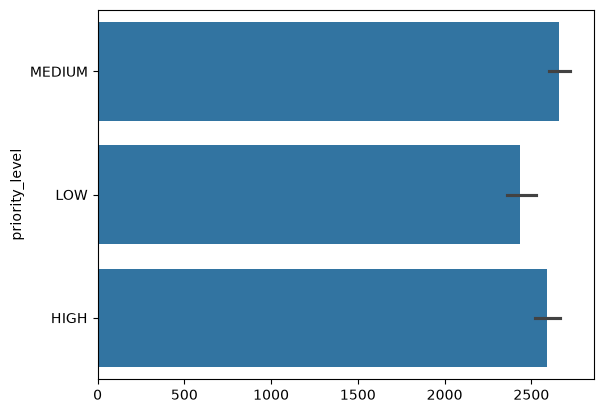

In [24]:
sns.barplot(data=incident_df['priority_level'])

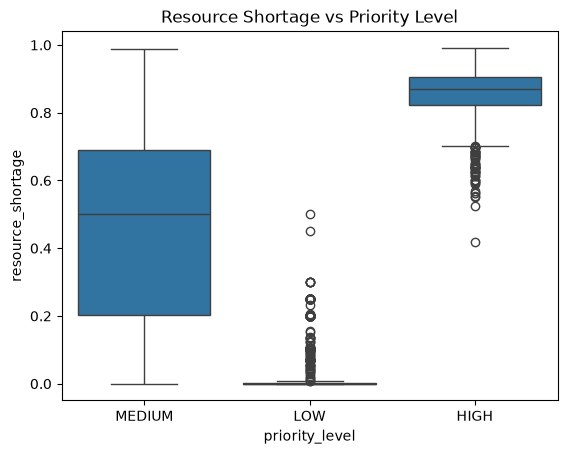

In [25]:
sns.boxplot(
    data=incident_df,
    x='priority_level',
    y='resource_shortage'
)

plt.title('Resource Shortage vs Priority Level')
plt.show()